In [1]:
%pip install polars scikit-learn matplotlib seaborn scipy umap-learn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Files in dataset: ['dns.txt', 'auth.txt', 'redteam.txt', 'flows.txt', 'proc.txt']

Shape: (40821591, 3)

Schema: Schema({'column_1': Int64, 'column_2': String, 'column_3': String})

First 5 rows:
shape: (5, 3)
┌──────────┬──────────┬──────────┐
│ column_1 ┆ column_2 ┆ column_3 │
│ ---      ┆ ---      ┆ ---      │
│ i64      ┆ str      ┆ str      │
╞══════════╪══════════╪══════════╡
│ 2        ┆ C4653    ┆ C5030    │
│ 2        ┆ C5782    ┆ C16712   │
│ 6        ┆ C1191    ┆ C419     │
│ 15       ┆ C3380    ┆ C22841   │
│ 18       ┆ C2436    ┆ C5030    │
└──────────┴──────────┴──────────┘

Basic Statistics:
shape: (9, 4)
┌────────────┬───────────────┬──────────┬──────────┐
│ statistic  ┆ column_1      ┆ column_2 ┆ column_3 │
│ ---        ┆ ---           ┆ ---      ┆ ---      │
│ str        ┆ f64           ┆ str      ┆ str      │
╞════════════╪═══════════════╪══════════╪══════════╡
│ count      ┆ 4.0821591e7   ┆ 40821591 ┆ 40821591 │
│ null_count ┆ 0.0           ┆ 0        ┆ 0        │
│

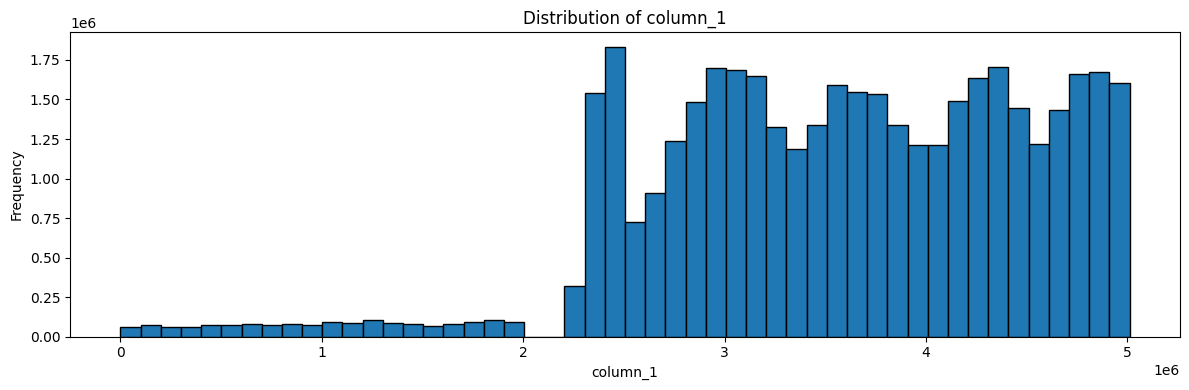

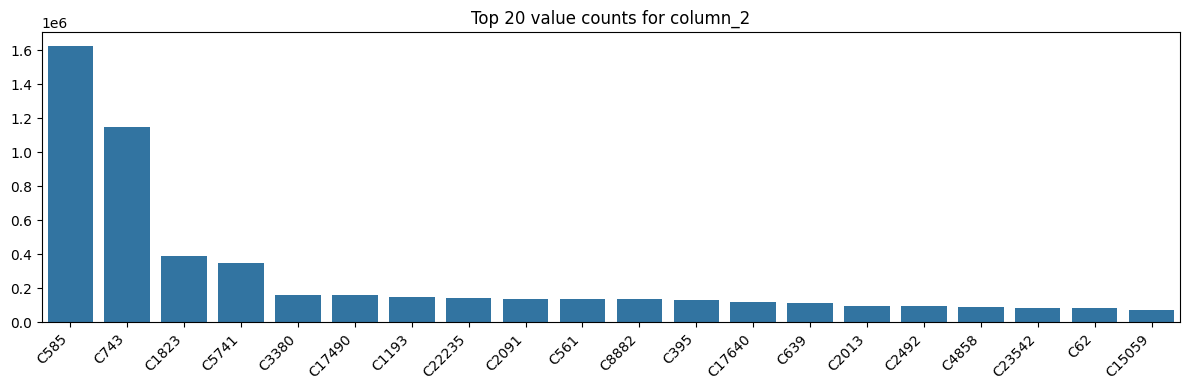

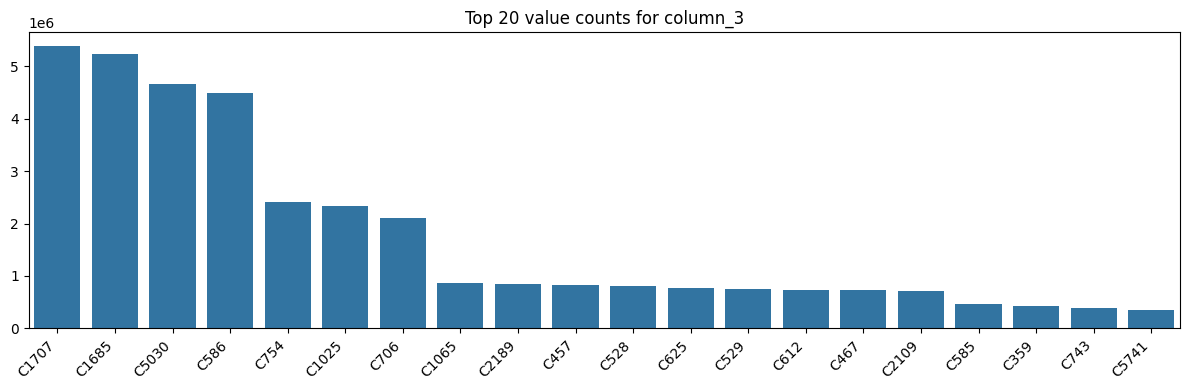

/var/folders/2v/bn5_gh1x1b14mb5bsw0zj3fh0000gn/T/ipykernel_36319/4019285987.py:56: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  time_series = df.group_by(time_col).count().sort(time_col)


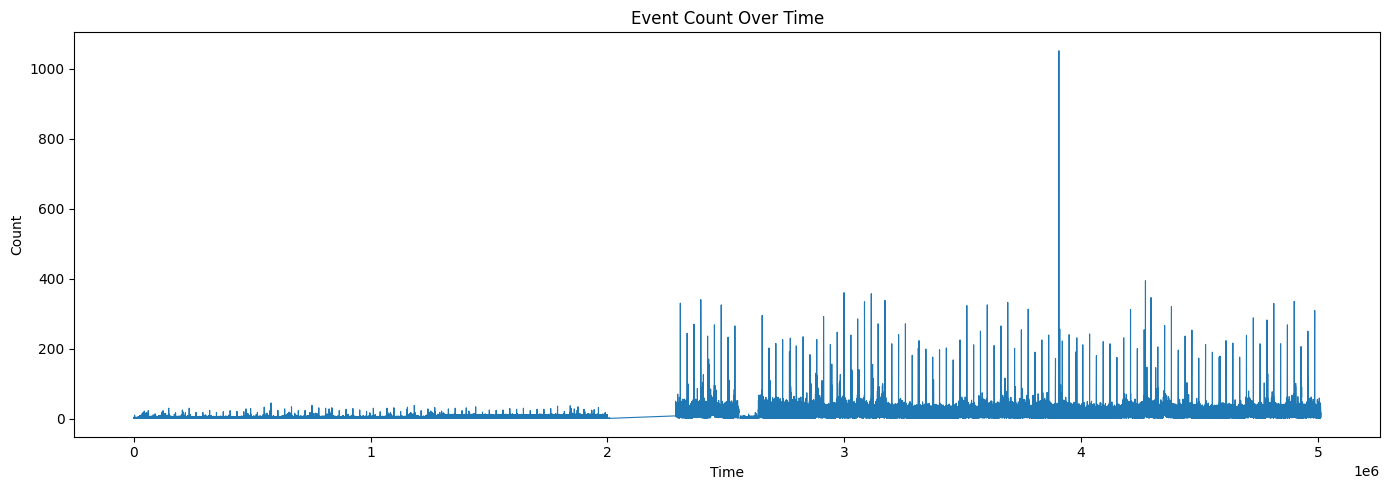

In [2]:
import polars as pl
import seaborn as sns
import os

import matplotlib.pyplot as plt

# Load the dataset
data_path = "./data/cyber1"
files = [f for f in os.listdir(data_path) if f.endswith(".txt")]
print("Files in dataset:", files)

# Load the first file (assuming CSV format)
df = pl.read_csv(os.path.join(data_path, files[0]), has_header=False, batch_size=10_000_000)
print("\nShape:", df.shape)
print("\nSchema:", df.schema)
print("\nFirst 5 rows:")
print(df.head())

# Basic statistics
print("\nBasic Statistics:")
print(df.describe())

# Check for null values
print("\nNull values per column:")
print(df.null_count())

# Plot distributions for numerical columns
num_cols = [col for col, dtype in df.schema.items() if dtype in [pl.Int32, pl.Int64, pl.Float32, pl.Float64]]

if num_cols:
    fig, axes = plt.subplots(len(num_cols), 1, figsize=(12, 4 * len(num_cols)))
    if len(num_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, num_cols):
        ax.hist(df[col].drop_nulls().to_list(), bins=50, edgecolor='black')
        ax.set_title(f"Distribution of {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# Plot value counts for categorical columns
cat_cols = [col for col, dtype in df.schema.items() if dtype == pl.Utf8]

for col in cat_cols[:5]:  # limit to first 5 categorical columns
    top_vals = df[col].value_counts().sort("count", descending=True).head(20)
    plt.figure(figsize=(12, 4))
    sns.barplot(x=top_vals[col].to_list(), y=top_vals["count"].to_list())
    plt.title(f"Top 20 value counts for {col}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Time-based analysis if a time column exists
time_col = df.columns[0]  # LANL cyber1 first column is typically time
time_series = df.group_by(time_col).count().sort(time_col)
plt.figure(figsize=(14, 5))
plt.plot(time_series[time_col].to_list(), time_series["count"].to_list(), linewidth=0.8)
plt.title("Event Count Over Time")
plt.xlabel("Time")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

/var/folders/2v/bn5_gh1x1b14mb5bsw0zj3fh0000gn/T/ipykernel_36319/752038958.py:24: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  row_count = auth_lf.select(pl.len().alias("rows")).collect(streaming=True)
/var/folders/2v/bn5_gh1x1b14mb5bsw0zj3fh0000gn/T/ipykernel_36319/752038958.py:25: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  null_counts = auth_lf.select([pl.col(c).null_count().alias(c) for c in col_names]).collect(streaming=True)


Rows:
shape: (1, 1)
┌────────────┐
│ rows       │
│ ---        │
│ u32        │
╞════════════╡
│ 1051430459 │
└────────────┘

Columns:
['time', 'src_user', 'dst_user', 'src_pc', 'dst_pc', 'auth_type', 'logon_type', 'auth_orient', 'success']

Null counts:
shape: (1, 9)
┌──────┬──────────┬──────────┬────────┬───┬───────────┬────────────┬─────────────┬─────────┐
│ time ┆ src_user ┆ dst_user ┆ src_pc ┆ … ┆ auth_type ┆ logon_type ┆ auth_orient ┆ success │
│ ---  ┆ ---      ┆ ---      ┆ ---    ┆   ┆ ---       ┆ ---        ┆ ---         ┆ ---     │
│ u32  ┆ u32      ┆ u32      ┆ u32    ┆   ┆ u32       ┆ u32        ┆ u32         ┆ u32     │
╞══════╪══════════╪══════════╪════════╪═══╪═══════════╪════════════╪═════════════╪═════════╡
│ 0    ┆ 0        ┆ 0        ┆ 0      ┆ … ┆ 0         ┆ 0          ┆ 0           ┆ 0       │
└──────┴──────────┴──────────┴────────┴───┴───────────┴────────────┴─────────────┴─────────┘

Sample rows:
shape: (5, 9)
┌──────┬──────────────┬──────────────┬────────┬───┬─

/var/folders/2v/bn5_gh1x1b14mb5bsw0zj3fh0000gn/T/ipykernel_36319/752038958.py:36: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  print(auth_lf.head(5).collect(streaming=True))
/var/folders/2v/bn5_gh1x1b14mb5bsw0zj3fh0000gn/T/ipykernel_36319/752038958.py:46: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)



Top 20 values for src_user:
shape: (20, 2)
┌──────────────────────┬──────────┐
│ src_user             ┆ count    │
│ ---                  ┆ ---      │
│ str                  ┆ u32      │
╞══════════════════════╪══════════╡
│ ANONYMOUS LOGON@C586 ┆ 17558000 │
│ U22@DOM1             ┆ 16595241 │
│ U66@DOM1             ┆ 11182081 │
│ C599$@DOM1           ┆ 8492841  │
│ C1114$@DOM1          ┆ 7714809  │
│ …                    ┆ …        │
│ U292@DOM1            ┆ 3930195  │
│ U346@DOM1            ┆ 3820551  │
│ C1065$@DOM1          ┆ 3809259  │
│ U7@DOM1              ┆ 3342035  │
│ U63@DOM1             ┆ 2595146  │
└──────────────────────┴──────────┘


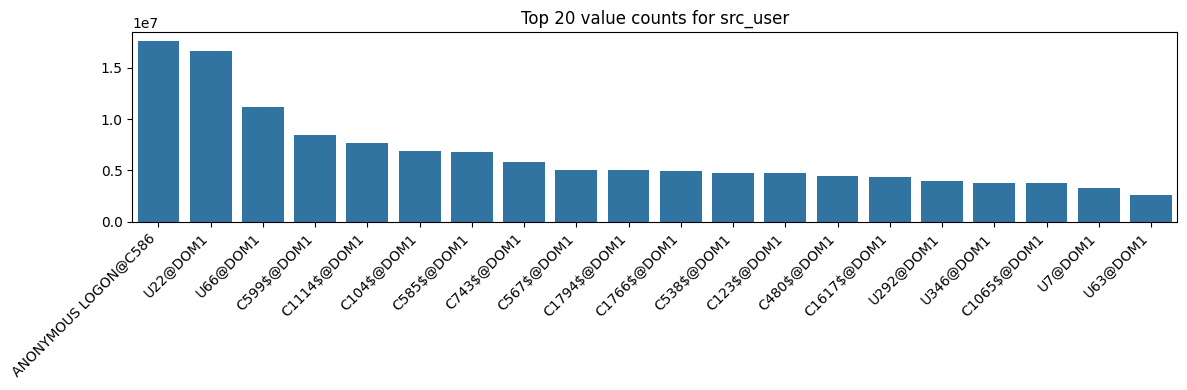

/var/folders/2v/bn5_gh1x1b14mb5bsw0zj3fh0000gn/T/ipykernel_36319/752038958.py:46: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)



Top 20 values for dst_user:
shape: (20, 2)
┌──────────────────────┬──────────┐
│ dst_user             ┆ count    │
│ ---                  ┆ ---      │
│ str                  ┆ u32      │
╞══════════════════════╪══════════╡
│ ANONYMOUS LOGON@C586 ┆ 17558000 │
│ U22@DOM1             ┆ 16595239 │
│ U66@DOM1             ┆ 11184266 │
│ C599$@DOM1           ┆ 8492841  │
│ C1114$@DOM1          ┆ 7714809  │
│ …                    ┆ …        │
│ U292@DOM1            ┆ 3954199  │
│ U346@DOM1            ┆ 3820551  │
│ C1065$@DOM1          ┆ 3800010  │
│ U7@DOM1              ┆ 3342747  │
│ U63@DOM1             ┆ 2594980  │
└──────────────────────┴──────────┘


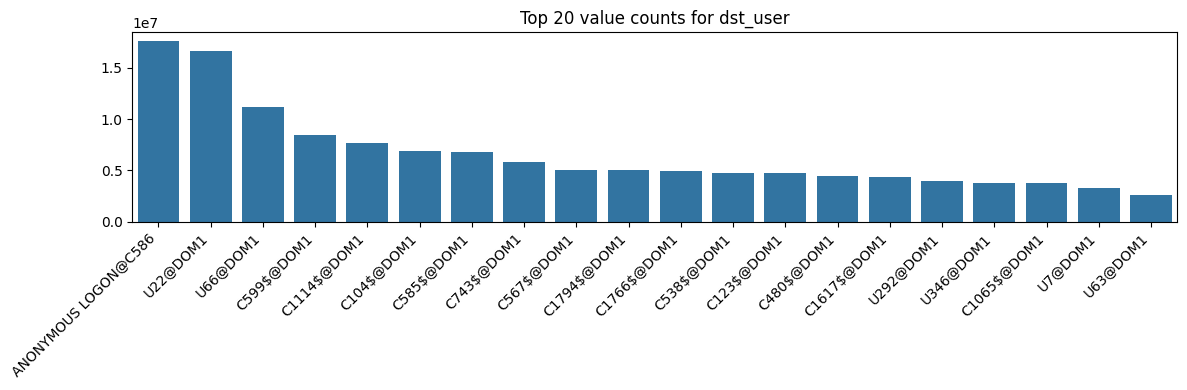

/var/folders/2v/bn5_gh1x1b14mb5bsw0zj3fh0000gn/T/ipykernel_36319/752038958.py:46: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)



Top 20 values for src_pc:
shape: (20, 2)
┌────────┬──────────┐
│ src_pc ┆ count    │
│ ---    ┆ ---      │
│ str    ┆ u32      │
╞════════╪══════════╡
│ C586   ┆ 55394572 │
│ C612   ┆ 37899880 │
│ C529   ┆ 36459263 │
│ C625   ┆ 36384663 │
│ C467   ┆ 36103345 │
│ …      ┆ …        │
│ C229   ┆ 6045817  │
│ C1115  ┆ 5812811  │
│ C743   ┆ 5505342  │
│ C101   ┆ 5384289  │
│ C1015  ┆ 5339141  │
└────────┴──────────┘


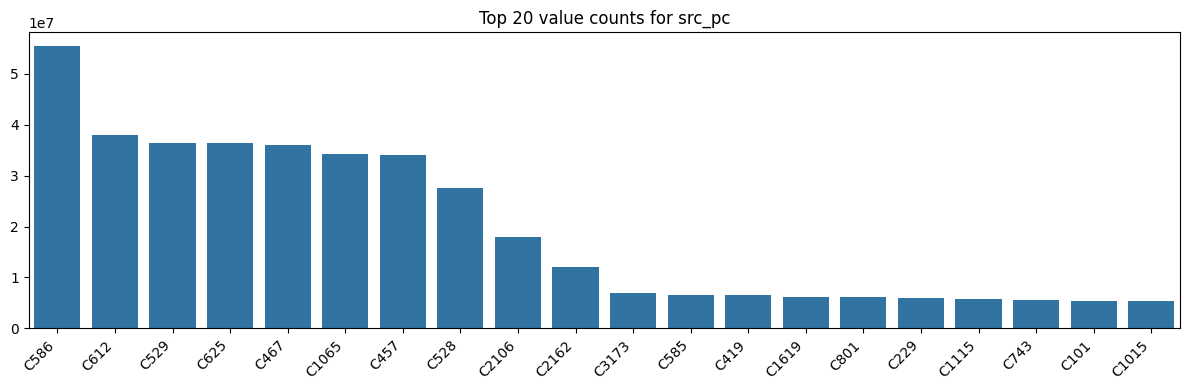

/var/folders/2v/bn5_gh1x1b14mb5bsw0zj3fh0000gn/T/ipykernel_36319/752038958.py:46: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)



Top 20 values for dst_pc:
shape: (20, 2)
┌────────┬───────────┐
│ dst_pc ┆ count     │
│ ---    ┆ ---       │
│ str    ┆ u32       │
╞════════╪═══════════╡
│ C586   ┆ 121232327 │
│ C612   ┆ 75369542  │
│ C529   ┆ 72674773  │
│ C625   ┆ 72161687  │
│ C467   ┆ 71962942  │
│ …      ┆ …         │
│ C553   ┆ 8234374   │
│ C1085  ┆ 7084119   │
│ C585   ┆ 7082165   │
│ C2327  ┆ 6983394   │
│ C523   ┆ 6975969   │
└────────┴───────────┘


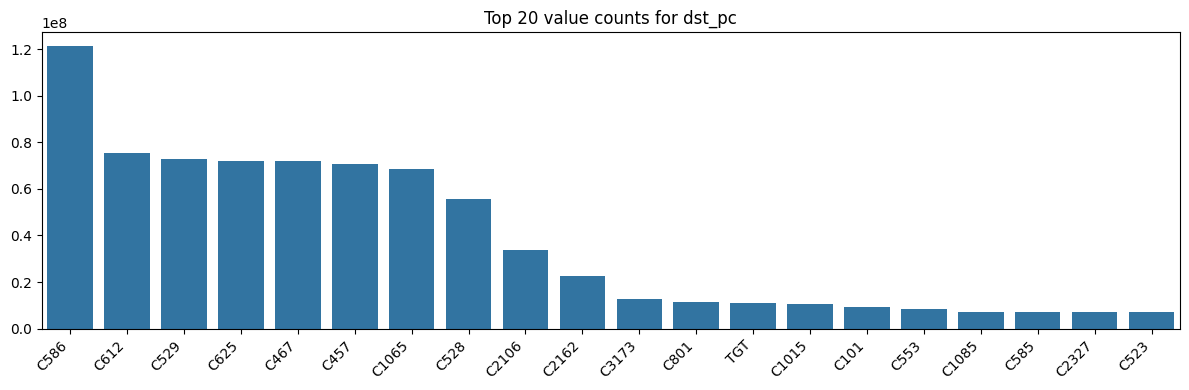

/var/folders/2v/bn5_gh1x1b14mb5bsw0zj3fh0000gn/T/ipykernel_36319/752038958.py:46: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)



Top 20 values for auth_type:
shape: (20, 2)
┌─────────────────────────────────┬───────────┐
│ auth_type                       ┆ count     │
│ ---                             ┆ ---       │
│ str                             ┆ u32       │
╞═════════════════════════════════╪═══════════╡
│ ?                               ┆ 583350819 │
│ Kerberos                        ┆ 362830725 │
│ Negotiate                       ┆ 55047638  │
│ NTLM                            ┆ 49341300  │
│ MICROSOFT_AUTHENTICATION_PACKA… ┆ 746676    │
│ …                               ┆ …         │
│ NETWARE_AUTHENTICATION_PACKAGE… ┆ 911       │
│ MICROSOFT_AUTHENTICATION_P      ┆ 658       │
│ Wave                            ┆ 525       │
│ MICROSOFT_AUTHENTICATI          ┆ 202       │
│ Setuid                          ┆ 167       │
└─────────────────────────────────┴───────────┘


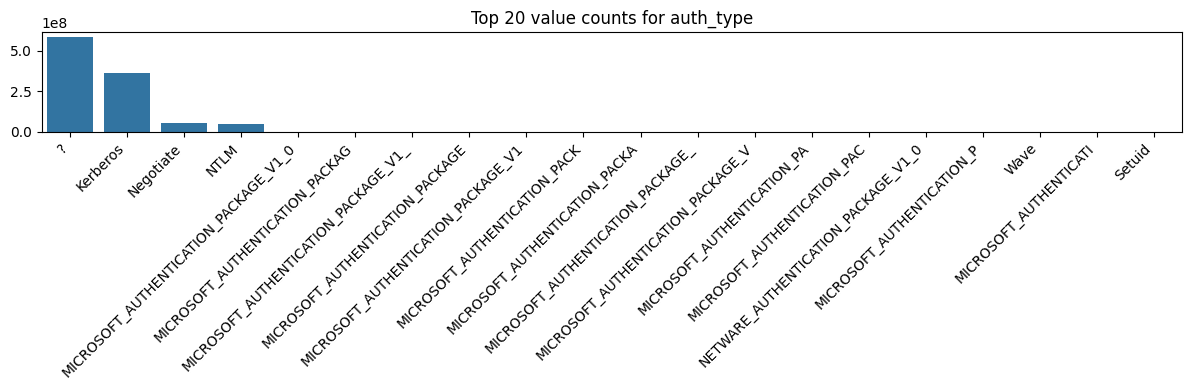

/var/folders/2v/bn5_gh1x1b14mb5bsw0zj3fh0000gn/T/ipykernel_36319/752038958.py:67: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)



Time-bucketed event counts (sample):
shape: (10, 2)
┌──────────┬─────────┐
│ time_bin ┆ count   │
│ ---      ┆ ---     │
│ i64      ┆ u32     │
╞══════════╪═════════╡
│ 0        ┆ 980268  │
│ 10000    ┆ 981306  │
│ 20000    ┆ 1947644 │
│ 30000    ┆ 2596536 │
│ 40000    ┆ 2376431 │
│ 50000    ┆ 2386850 │
│ 60000    ┆ 1853016 │
│ 70000    ┆ 1603733 │
│ 80000    ┆ 1595408 │
│ 90000    ┆ 1609586 │
└──────────┴─────────┘


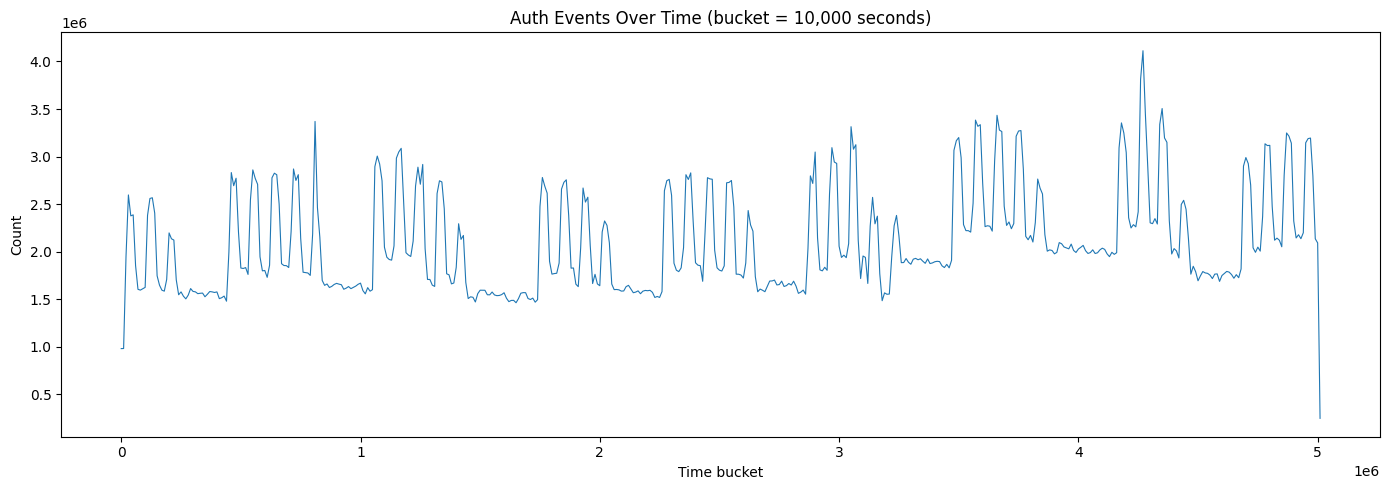

/var/folders/2v/bn5_gh1x1b14mb5bsw0zj3fh0000gn/T/ipykernel_36319/752038958.py:87: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)



Success distribution:
shape: (2, 2)
┌─────────┬────────────┐
│ success ┆ count      │
│ ---     ┆ ---        │
│ str     ┆ u32        │
╞═════════╪════════════╡
│ Success ┆ 1038590151 │
│ Fail    ┆ 12840308   │
└─────────┴────────────┘


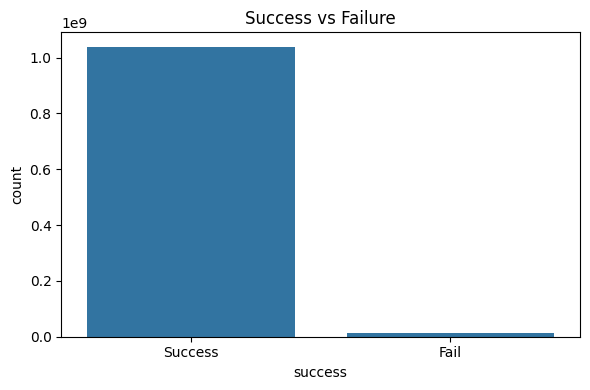

In [3]:
# EDA for large auth.txt using Polars lazy API
auth_path = os.path.join(data_path, "auth.txt")
if not os.path.exists(auth_path):
    raise FileNotFoundError(f"File not found: {auth_path}")

# Detect column count from a small sample
sample = pl.read_csv(auth_path, has_header=False, n_rows=5)
default_cols = [
    "time", "src_user", "dst_user", "src_pc", "dst_pc",
    "auth_type", "logon_type", "auth_orient", "success"
]
col_names = default_cols if sample.width == len(default_cols) else [f"col_{i}" for i in range(sample.width)]

# Lazy scan for large-file processing
auth_lf = pl.scan_csv(
    auth_path,
    has_header=False,
    new_columns=col_names,
    infer_schema_length=10_000,
    ignore_errors=True
)

# Basic shape and null counts
row_count = auth_lf.select(pl.len().alias("rows")).collect(engine="streaming")
null_counts = auth_lf.select([pl.col(c).null_count().alias(c) for c in col_names]).collect(engine="streaming")

print("Rows:")
print(row_count)
print("\nColumns:")
print(col_names)
print("\nNull counts:")
print(null_counts)

# Quick sample
print("\nSample rows:")
print(auth_lf.head(5).collect(engine="streaming"))

# Top values for categorical columns (first 5 non-time columns)
cat_cols = [c for c in col_names if c != "time"][:5]
for c in cat_cols:
    top_vals = (
        auth_lf.group_by(c)
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
        .head(20)
        .collect(engine="streaming")
    )
    print(f"\nTop 20 values for {c}:")
    print(top_vals)

    plt.figure(figsize=(12, 4))
    sns.barplot(x=top_vals[c].cast(pl.Utf8).to_list(), y=top_vals["count"].to_list())
    plt.title(f"Top 20 value counts for {c}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Time trend (bucketed) if time column exists and is numeric/castable
if "time" in col_names:
    time_trend = (
        auth_lf.with_columns(pl.col("time").cast(pl.Int64, strict=False).alias("time"))
        .drop_nulls(["time"])
        .with_columns((pl.col("time") // 10_000 * 10_000).alias("time_bin"))
        .group_by("time_bin")
        .agg(pl.len().alias("count"))
        .sort("time_bin")
        .collect(engine="streaming")
    )

    print("\nTime-bucketed event counts (sample):")
    print(time_trend.head(10))

    plt.figure(figsize=(14, 5))
    plt.plot(time_trend["time_bin"].to_list(), time_trend["count"].to_list(), linewidth=0.8)
    plt.title("Auth Events Over Time (bucket = 10,000 seconds)")
    plt.xlabel("Time bucket")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Success/failure distribution if available
if "success" in col_names:
    success_dist = (
        auth_lf.group_by("success")
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
        .collect(engine="streaming")
    )
    print("\nSuccess distribution:")
    print(success_dist)

    plt.figure(figsize=(6, 4))
    sns.barplot(x=success_dist["success"].cast(pl.Utf8).to_list(), y=success_dist["count"].to_list())
    plt.title("Success vs Failure")
    plt.xlabel("success")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

Rows:
shape: (1, 1)
┌──────┐
│ rows │
│ ---  │
│ u32  │
╞══════╡
│ 749  │
└──────┘

Columns:
['time', 'user', 'src_pc', 'dst_pc']

Null counts:
shape: (1, 4)
┌──────┬──────┬────────┬────────┐
│ time ┆ user ┆ src_pc ┆ dst_pc │
│ ---  ┆ ---  ┆ ---    ┆ ---    │
│ u32  ┆ u32  ┆ u32    ┆ u32    │
╞══════╪══════╪════════╪════════╡
│ 0    ┆ 0    ┆ 0      ┆ 0      │
└──────┴──────┴────────┴────────┘

Sample rows:
shape: (10, 4)
┌────────┬────────────┬────────┬────────┐
│ time   ┆ user       ┆ src_pc ┆ dst_pc │
│ ---    ┆ ---        ┆ ---    ┆ ---    │
│ i64    ┆ str        ┆ str    ┆ str    │
╞════════╪════════════╪════════╪════════╡
│ 150885 ┆ U620@DOM1  ┆ C17693 ┆ C1003  │
│ 151036 ┆ U748@DOM1  ┆ C17693 ┆ C305   │
│ 151648 ┆ U748@DOM1  ┆ C17693 ┆ C728   │
│ 151993 ┆ U6115@DOM1 ┆ C17693 ┆ C1173  │
│ 153792 ┆ U636@DOM1  ┆ C17693 ┆ C294   │
│ 155219 ┆ U748@DOM1  ┆ C17693 ┆ C5693  │
│ 155399 ┆ U748@DOM1  ┆ C17693 ┆ C152   │
│ 155460 ┆ U748@DOM1  ┆ C17693 ┆ C2341  │
│ 155591 ┆ U748@DOM1  ┆ C1769

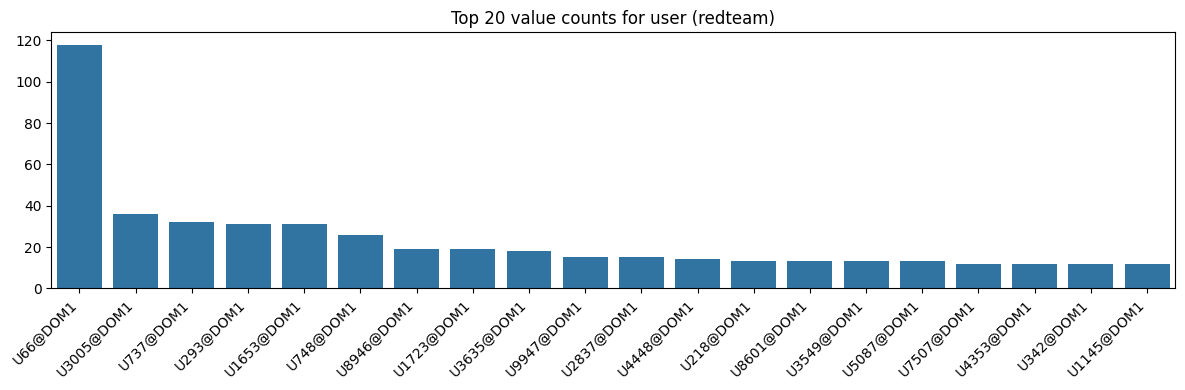


Top 20 values for src_pc:
shape: (4, 2)
┌────────┬───────┐
│ src_pc ┆ count │
│ ---    ┆ ---   │
│ str    ┆ u32   │
╞════════╪═══════╡
│ C17693 ┆ 701   │
│ C22409 ┆ 26    │
│ C19932 ┆ 19    │
│ C18025 ┆ 3     │
└────────┴───────┘


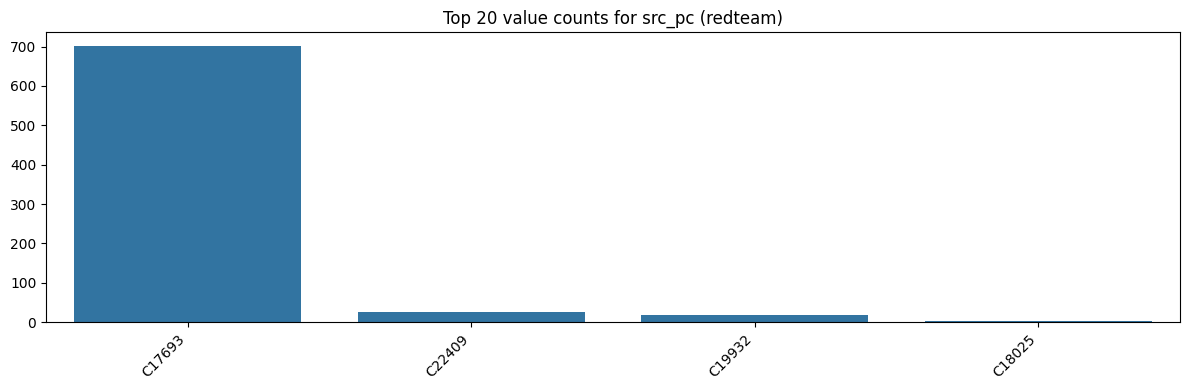


Top 20 values for dst_pc:
shape: (20, 2)
┌────────┬───────┐
│ dst_pc ┆ count │
│ ---    ┆ ---   │
│ str    ┆ u32   │
╞════════╪═══════╡
│ C2388  ┆ 27    │
│ C754   ┆ 26    │
│ C2519  ┆ 21    │
│ C395   ┆ 15    │
│ C1015  ┆ 15    │
│ …      ┆ …     │
│ C1737  ┆ 7     │
│ C3019  ┆ 7     │
│ C457   ┆ 7     │
│ C148   ┆ 6     │
│ C368   ┆ 6     │
└────────┴───────┘


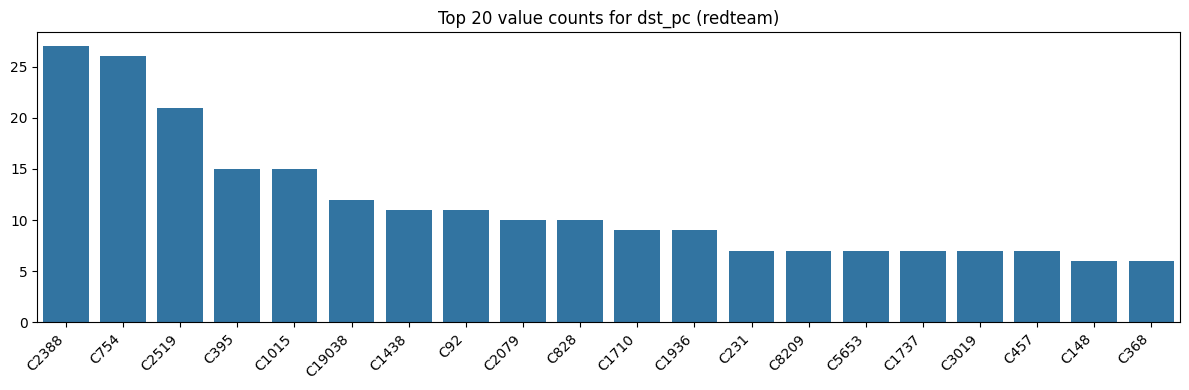


Time-bucketed event counts (sample):
shape: (10, 2)
┌──────────┬───────┐
│ time_bin ┆ count │
│ ---      ┆ ---   │
│ i64      ┆ u32   │
╞══════════╪═══════╡
│ 150000   ┆ 10    │
│ 210000   ┆ 4     │
│ 220000   ┆ 9     │
│ 230000   ┆ 2     │
│ 460000   ┆ 11    │
│ 470000   ┆ 3     │
│ 480000   ┆ 6     │
│ 490000   ┆ 1     │
│ 570000   ┆ 1     │
│ 580000   ┆ 2     │
└──────────┴───────┘


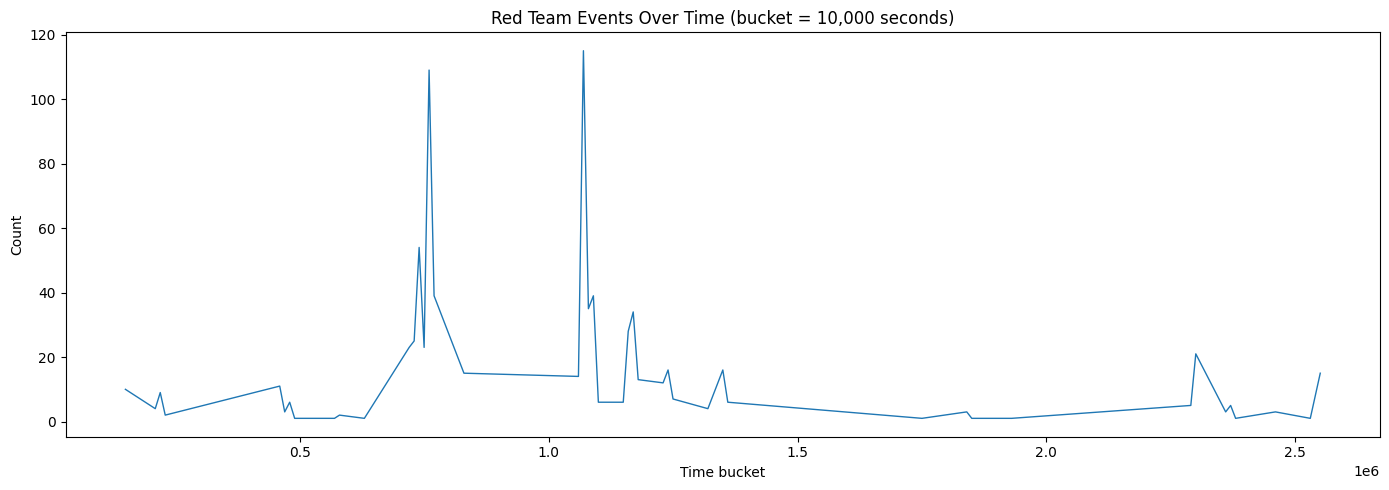

In [4]:
# EDA for redteam.txt using Polars lazy API
redteam_path = os.path.join(data_path, "redteam.txt")
if not os.path.exists(redteam_path):
    raise FileNotFoundError(f"File not found: {redteam_path}")

# Detect schema width and set column names
red_sample = pl.read_csv(redteam_path, has_header=False, n_rows=5)
red_default_cols = ["time", "user", "src_pc", "dst_pc"]
red_col_names = red_default_cols if red_sample.width == len(red_default_cols) else [f"col_{i}" for i in range(red_sample.width)]

red_lf = pl.scan_csv(
    redteam_path,
    has_header=False,
    new_columns=red_col_names,
    infer_schema_length=10_000,
    ignore_errors=True
)

# Basic overview
red_rows = red_lf.select(pl.len().alias("rows")).collect(engine="streaming")
red_nulls = red_lf.select([pl.col(c).null_count().alias(c) for c in red_col_names]).collect(engine="streaming")

print("Rows:")
print(red_rows)
print("\nColumns:")
print(red_col_names)
print("\nNull counts:")
print(red_nulls)
print("\nSample rows:")
print(red_lf.head(10).collect(engine="streaming"))

# Top values for categorical columns
red_cat_cols = [c for c in red_col_names if c != "time"][:5]
for c in red_cat_cols:
    red_top = (
        red_lf.group_by(c)
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
        .head(20)
        .collect(engine="streaming")
    )
    print(f"\nTop 20 values for {c}:")
    print(red_top)

    plt.figure(figsize=(12, 4))
    sns.barplot(x=red_top[c].cast(pl.Utf8).to_list(), y=red_top["count"].to_list())
    plt.title(f"Top 20 value counts for {c} (redteam)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Time trend
if "time" in red_col_names:
    red_time_trend = (
        red_lf.with_columns(pl.col("time").cast(pl.Int64, strict=False))
        .drop_nulls(["time"])
        .with_columns((pl.col("time") // 10_000 * 10_000).alias("time_bin"))
        .group_by("time_bin")
        .agg(pl.len().alias("count"))
        .sort("time_bin")
        .collect(engine="streaming")
    )

    print("\nTime-bucketed event counts (sample):")
    print(red_time_trend.head(10))

    plt.figure(figsize=(14, 5))
    plt.plot(red_time_trend["time_bin"].to_list(), red_time_trend["count"].to_list(), linewidth=1.0)
    plt.title("Red Team Events Over Time (bucket = 10,000 seconds)")
    plt.xlabel("Time bucket")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [5]:
# Label auth events using redteam events (1 = redteam/malicious, 0 = normal)

# Build redteam keys aligned to auth schema
red_keys = (
    red_lf.select(
        pl.col("time").cast(pl.Int64, strict=False).alias("time"),
        pl.col("user").alias("src_user"),
        pl.col("src_pc"),
        pl.col("dst_pc"),
    )
    .unique()
    .with_columns(pl.lit(1).alias("label"))
)

# Prepare auth and join labels
labeled_auth_lf = (
    auth_lf.with_columns(pl.col("time").cast(pl.Int64, strict=False).alias("time"))
    .join(red_keys, on=["time", "src_user", "src_pc", "dst_pc"], how="left")
    .with_columns(pl.col("label").fill_null(0).cast(pl.Int8))
)

# Quick check: class distribution
label_dist = (
    labeled_auth_lf.group_by("label")
    .agg(pl.len().alias("count"))
    .sort("label")
    .collect(engine="streaming")
)
print(label_dist)

# Optional sample of labeled rows
print(labeled_auth_lf.filter(pl.col("label") == 1).head(10).collect(engine="streaming"))

shape: (2, 2)
┌───────┬────────────┐
│ label ┆ count      │
│ ---   ┆ ---        │
│ i8    ┆ u32        │
╞═══════╪════════════╡
│ 0     ┆ 1051429757 │
│ 1     ┆ 702        │
└───────┴────────────┘
shape: (10, 10)
┌────────┬────────────┬────────────┬────────┬───┬────────────┬─────────────┬─────────┬───────┐
│ time   ┆ src_user   ┆ dst_user   ┆ src_pc ┆ … ┆ logon_type ┆ auth_orient ┆ success ┆ label │
│ ---    ┆ ---        ┆ ---        ┆ ---    ┆   ┆ ---        ┆ ---         ┆ ---     ┆ ---   │
│ i64    ┆ str        ┆ str        ┆ str    ┆   ┆ str        ┆ str         ┆ str     ┆ i8    │
╞════════╪════════════╪════════════╪════════╪═══╪════════════╪═════════════╪═════════╪═══════╡
│ 150885 ┆ U620@DOM1  ┆ U620@DOM1  ┆ C17693 ┆ … ┆ Network    ┆ LogOn       ┆ Success ┆ 1     │
│ 151036 ┆ U748@DOM1  ┆ U748@DOM1  ┆ C17693 ┆ … ┆ Network    ┆ LogOn       ┆ Success ┆ 1     │
│ 151648 ┆ U748@DOM1  ┆ U748@DOM1  ┆ C17693 ┆ … ┆ Network    ┆ LogOn       ┆ Success ┆ 1     │
│ 151993 ┆ U6115@DOM1 ┆ U6